# Seeded Run 1 — 4-Class × 64 Neurons (Colab Pilot)

**Single-seed pilot** to test whether 64 hidden neurons reverses the heterogeneity trend seen at 32 neurons.

| | 32-neuron | 64-neuron pilot |
|---|---|---|
| Hidden neurons | 32 | **64** |
| Recurrent params | 1,024 | **4,096** (4×) |
| Batch size | 512 | **256** (more VRAM per sample) |
| Epochs | 50 | 50 |
| Seeds | 10 | **1 (101)** — pilot |
| Est. time | ~2.3h/seed | **~5h** |

**Hypothesis:** At 32 neurons, some τ_m draws produce irrecoverably poor dynamics. At 64 neurons, redundancy compensates — heterogeneity should show a positive delta.

## 0. Mount Google Drive & Locate Project

In [21]:
# ── Mount Google Drive ──────────────────────────────────────────────
from google.colab import drive
drive.mount('/content/drive')

# ── Locate project root on Drive ──
import os
from pathlib import Path

_DRIVE_BASE = "/content/drive/MyDrive"
if not os.path.exists(_DRIVE_BASE):
    _DRIVE_BASE = "/content/drive/My Drive"

_candidates = [
    f"{_DRIVE_BASE}/research project (SNN Info Theory)",
    f"{_DRIVE_BASE}/SNN Info Theory",
    f"{_DRIVE_BASE}/research project",
]

DRIVE_ROOT = None
for _c in _candidates:
    if os.path.exists(_c):
        DRIVE_ROOT = _c
        print(f"  ✓ Found project at: {DRIVE_ROOT}")
        break

if DRIVE_ROOT is None:
    print(f"  ✗ Project folder not found. Contents of {_DRIVE_BASE}/:")
    for _item in os.listdir(_DRIVE_BASE):
        print(f"    - {_item}")
    raise FileNotFoundError("Upload the project folder to Google Drive.")

DRIVE_PROJECT = f"{DRIVE_ROOT}/Project Files"
DRIVE_DATA = f"{DRIVE_ROOT}/data/shd"
DRIVE_WIMFO = f"{DRIVE_ROOT}/wimfo"
DRIVE_PAPER = f"{DRIVE_ROOT}/neural_heterogeneity/SuGD_code"

_required = [
    ("seeded_runs_common.py", f"{DRIVE_PROJECT}/seeded_runs_common.py"),
    ("shd_train.h5", f"{DRIVE_DATA}/shd_train.h5"),
    ("shd_test.h5", f"{DRIVE_DATA}/shd_test.h5"),
    ("model.py", f"{DRIVE_PAPER}/model.py"),
    ("layers.py", f"{DRIVE_PAPER}/layers.py"),
]
_missing = []
for _name, _path in _required:
    ok = os.path.exists(_path)
    print(f"  {'✓' if ok else '✗'} {_name}")
    if not ok:
        _missing.append(_name)
if _missing:
    raise FileNotFoundError(f"Missing: {', '.join(_missing)}")

import importlib
for pkg in ["tables"]:
    try:
        importlib.import_module(pkg)
    except ImportError:
        !pip install -q {pkg}

print("  ✓ Ready.")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
  ✓ Found project at: /content/drive/MyDrive/research project (SNN Info Theory)
  ✓ seeded_runs_common.py
  ✓ shd_train.h5
  ✓ shd_test.h5
  ✓ model.py
  ✓ layers.py
  ✓ Ready.


## 1. Imports & Path Setup

In [22]:
import sys
sys.path.insert(0, DRIVE_PROJECT)
sys.path.insert(0, str(DRIVE_WIMFO))
sys.path.insert(0, str(DRIVE_PAPER))

from pathlib import Path
import importlib

import numpy as np
import pandas as pd
import torch
from IPython.display import display

import seeded_runs_common as seeded_runs_common

# ── Override paths for Colab (no reload — reload resets to Windows) ─
_COLAB_BASE = Path(DRIVE_ROOT)
seeded_runs_common.PROJECT_ROOT = _COLAB_BASE
seeded_runs_common.PROJECT_FILES = _COLAB_BASE / "Project Files"
seeded_runs_common.WIMFO_ROOT = _COLAB_BASE / "wimfo"
seeded_runs_common.PAPER_ROOT = _COLAB_BASE / "neural_heterogeneity" / "SuGD_code"
seeded_runs_common.CHECKPOINT_ROOT = seeded_runs_common.PROJECT_FILES / "Checkpoints" / "SeededRuns"
seeded_runs_common.TAU_ARTIFACT_PATH = _COLAB_BASE / "Tau from 15 epoch run.json"
seeded_runs_common.SHD_TRAIN = _COLAB_BASE / "data" / "shd" / "shd_train.h5"
seeded_runs_common.SHD_TEST = _COLAB_BASE / "data" / "shd" / "shd_test.h5"

CHECKPOINT_ROOT = seeded_runs_common.CHECKPOINT_ROOT
DEVICE = seeded_runs_common.DEVICE
SHD_TEST = seeded_runs_common.SHD_TEST
SHD_TRAIN = seeded_runs_common.SHD_TRAIN
TASKS = seeded_runs_common.TASKS
build_pair_summary_row = seeded_runs_common.build_pair_summary_row
build_sampling_preview_rows = seeded_runs_common.build_sampling_preview_rows
build_seeded_pair = seeded_runs_common.build_seeded_pair
get_pair_checkpoint_paths = seeded_runs_common.get_pair_checkpoint_paths
load_default_caches = seeded_runs_common.load_default_caches
read_manifest_rows = seeded_runs_common.read_manifest_rows
run_pair_training = seeded_runs_common.run_pair_training
upsert_rows = seeded_runs_common.upsert_rows
write_manifest_rows = seeded_runs_common.write_manifest_rows

RUN_LABEL = "seeded_run_1_64n"     # separate from 32-neuron runs
TASK_KEY = "4class"
MEM_DISTRIBUTION_FAMILY = "lognormal"
MASTER_SEEDS = [101, 202, 210, 340, 440, 550, 660, 710, 820, 930]  # 10 seeds

RUN_DIR = CHECKPOINT_ROOT / RUN_LABEL / f"{TASK_KEY}_{MEM_DISTRIBUTION_FAMILY}"
RESULT_STEM = RUN_DIR / f"{RUN_LABEL}_checkpoint_summary"
PAIR_STEM = RUN_DIR / f"{RUN_LABEL}_pair_summary"
PAIRED_ACC_CSV = RUN_DIR / f"{RUN_LABEL}_paired_accuracy.csv"

TASK_DEF = TASKS[TASK_KEY]

print(f"Device: {DEVICE}")
print(f"GPU: {torch.cuda.get_device_name(0) if DEVICE.type == 'cuda' else 'N/A'}")
if DEVICE.type == 'cuda':
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"Run label: {RUN_LABEL}")
print(f"Task: {TASK_DEF['task_name']} ({TASK_DEF['nb_outputs']} outputs)")

Device: cuda
GPU: NVIDIA A100-SXM4-40GB
VRAM: 42.4 GB
Run label: seeded_run_1_64n
Task: 4class_parity_language (4 outputs)


## 2. Verification

In [23]:
assert TASK_KEY == "4class"
assert TASK_DEF["nb_outputs"] == 4

preview = build_seeded_pair(
    master_seed=MASTER_SEEDS[0],
    task_key=TASK_KEY,
    mem_distribution_family=MEM_DISTRIBUTION_FAMILY,
)
preview_meta = preview["metadata"]
assert preview_meta["linear_sync_verified"]
assert preview_meta["hom_hidden_tau_unique"] == 1

sampling_rows = build_sampling_preview_rows(
    MASTER_SEEDS, task_key=TASK_KEY, mem_distribution_family=MEM_DISTRIBUTION_FAMILY,
)
sampling_df = pd.DataFrame(sampling_rows)
display(sampling_df)
print("✓ Verification passed — linear sync OK, τ_m samples unique.")

,pair_seed,task_key,task_name,mem_distribution_family,linear_sync_verified,hetero_hidden_tau_unique,hom_hidden_tau_unique,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,sample_matches_previous
0,101,4class,4class_parity_language,lognormal,True,57,1,26.692505,3.410472,99.749887,39.909489,31.797022,False
1,202,4class,4class_parity_language,lognormal,True,56,1,27.118263,2.222559,99.749887,39.345280,31.215105,False
2,210,4class,4class_parity_language,lognormal,True,59,1,24.818521,3.264135,99.749887,37.145663,30.552753,False
3,340,4class,4class_parity_language,lognormal,True,60,1,21.949762,2.072141,99.749887,33.064951,28.652600,False
4,440,4class,4class_parity_language,lognormal,True,55,1,30.808003,2.192077,99.749887,43.835586,32.912114,False
5,550,4class,4class_parity_language,lognormal,True,56,1,27.526460,2.072141,99.749887,40.529044,31.294801,False
6,660,4class,4class_parity_language,lognormal,True,61,1,20.113731,2.886083,99.749887,29.953234,26.841652,False
7,710,4class,4class_parity_language,lognormal,True,61,1,21.640537,4.028925,99.749887,31.029622,27.142941,False
8,820,4class,4class_parity_language,lognormal,True,59,1,27.451118,2.279137,99.749887,37.817758,28.847356,False
9,930,4class,4class_parity_language,lognormal,True,60,1,22.388218,3.262524,99.749887,30.778635,25.671847,False


✓ Verification passed — linear sync OK, τ_m samples unique.


## 3. Load Caches & Apply 64-Neuron Configuration

In [24]:
train_cache, test_cache = load_default_caches()

Pre-loading SHD training data into RAM...
  SHDCache: 8156 samples loaded from shd_train.h5
Pre-loading SHD test data into RAM...
  SHDCache: 2264 samples loaded from shd_test.h5


In [25]:
# ── 64-Neuron Configuration (Perez-Nieves aligned) ─────────────────
#   Paper-matching changes:
#     • train_ab=1 (hetero τ learnable) — was frozen
#     • train_hom_ab=1 (homo τ learnable) — was frozen
#     • weight_decay=0 for hetero — heterogeneity IS the regularizer
#     • weight_decay=1e-4 for homo only (set globally, overridden for hetero)
#   Speed optimizations (do not affect τ mechanism):
#     • nb_recurrent=64 (was 128 in paper)
#     • batch_size=256, epochs=50 max, early_stop=10
#     • lr=2e-3, ReduceLROnPlateau(patience=5)
#   NOTE: train_ab=1 adds <5% compute overhead (136 extra τ params out of 4K+)

import torch

if torch.cuda.is_available():
    torch.backends.cudnn.benchmark = True

seeded_runs_common.BASE_PRMS["nb_recurrent"] = 64
seeded_runs_common.BASE_PRMS["batch_size"] = 256
seeded_runs_common.BASE_PRMS["nb_epochs"] = 50
seeded_runs_common.BASE_PRMS["early_stop_patience"] = 10
seeded_runs_common.BASE_PRMS["optimizer"] = "adam"
seeded_runs_common.BASE_PRMS["weight_decay"] = 1e-4     # for homo only; hetero overrides to 0
seeded_runs_common.BASE_PRMS["lr"] = 2e-3
seeded_runs_common.BASE_PRMS["lr_ab"] = 2e-3
seeded_runs_common.BASE_PRMS["lr_patience"] = 5
seeded_runs_common.BASE_PRMS["lr_factor"] = 0.5
seeded_runs_common.BASE_PRMS["lr_min"] = 5e-5
seeded_runs_common.BASE_PRMS["compile_model"] = False

print("64-neuron configuration (Perez-Nieves aligned):")
print(f"  nb_recurrent:  {seeded_runs_common.BASE_PRMS['nb_recurrent']}")
print(f"  τ training:    hetero=train_ab=1, homo=train_hom_ab=1 (learnable)")
print(f"  weight_decay:  homo={seeded_runs_common.BASE_PRMS['weight_decay']}, hetero=0")
print(f"  batch_size:    {seeded_runs_common.BASE_PRMS['batch_size']}")
print(f"  lr / lr_ab:    {seeded_runs_common.BASE_PRMS['lr']:.0e}")
print(f"  epochs:        {seeded_runs_common.BASE_PRMS['nb_epochs']} max (early stop patience=10)")
print(f"  LR scheduler:  ReduceLROnPlateau(patience=5)")
print(f"  τ param overhead: ~136 extra params (<5% compute)")


64-neuron configuration (Perez-Nieves aligned):
  nb_recurrent:  64
  τ training:    hetero=train_ab=1, homo=train_hom_ab=1 (learnable)
  weight_decay:  homo=0.0001, hetero=0
  batch_size:    256
  lr / lr_ab:    2e-03
  epochs:        50 max (early stop patience=10)
  LR scheduler:  ReduceLROnPlateau(patience=5)
  τ param overhead: ~136 extra params (<5% compute)


## 4. Training Helpers

In [26]:
CHECKPOINT_KEY_FIELDS = ["pair_seed", "pair_role"]
PAIR_KEY_FIELDS = ["pair_seed"]

def show_run_status():
    ckpt = pd.DataFrame(read_manifest_rows(RESULT_STEM))
    pairs = pd.DataFrame(read_manifest_rows(PAIR_STEM))
    if not ckpt.empty:
        ckpt = ckpt.sort_values(["pair_seed", "pair_role"]).reset_index(drop=True)
    if not pairs.empty:
        pairs = pairs.sort_values("pair_seed").reset_index(drop=True)
    paired = pd.DataFrame()
    if not ckpt.empty:
        paired = ckpt.pivot(index="pair_seed", columns="pair_role", values="final_test_acc")
        paired = paired.reset_index().sort_values("pair_seed").reset_index(drop=True)
        paired.columns.name = None
        if "heterogeneous_sampled" in paired.columns and "homogeneous_anchor" in paired.columns:
            paired["hetero_minus_hom"] = paired["heterogeneous_sampled"] - paired["homogeneous_anchor"]
            paired.to_csv(PAIRED_ACC_CSV, index=False)
    return pairs, ckpt, paired

def train_one_seed(master_seed):
    run_rows, pair_meta = run_pair_training(
        master_seed=master_seed, train_cache=train_cache, test_cache=test_cache,
        task_key=TASK_KEY, mem_distribution_family=MEM_DISTRIBUTION_FAMILY,
        run_label=RUN_LABEL, skip_existing=True,
    )
    write_manifest_rows(upsert_rows(read_manifest_rows(RESULT_STEM), run_rows, CHECKPOINT_KEY_FIELDS), RESULT_STEM)
    write_manifest_rows(upsert_rows(read_manifest_rows(PAIR_STEM), [build_pair_summary_row(pair_meta)], PAIR_KEY_FIELDS), PAIR_STEM)
    pairs, ckpt, paired = show_run_status()
    seed_df = ckpt[ckpt["pair_seed"] == master_seed].reset_index(drop=True)
    return seed_df, pairs, ckpt, paired

print("Helpers ready. Chance: 25.0%")

Helpers ready. Chance: 25.0%


## 5. Train Seed 101 (64 Neurons)

In [27]:
# Seed 101 — 64-neuron pilot
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(101)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 101].reset_index(drop=True))


Seed 101 :: reusing existing homogeneous_anchor checkpoint...

Seed 101 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,101,heterogeneous_sampled,0.662102,0.934457,3405.146820
1,101,homogeneous_anchor,0.581714,1.054689,3406.662314


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,101,4class,4class_parity_language,lognormal,10.0,26.692505,3.410472,99.749887,39.909489,31.797022,57,1,True,6


In [28]:
# Seed 202
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(202)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 202].reset_index(drop=True))



Seed 202 :: reusing existing homogeneous_anchor checkpoint...

Seed 202 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,202,heterogeneous_sampled,0.694346,0.969237,3566.808181
1,202,homogeneous_anchor,0.569788,1.001398,2210.048462


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,202,4class,4class_parity_language,lognormal,10.0,27.118263,2.222559,99.749887,39.34528,31.215105,56,1,True,6


In [29]:
# Seed 210
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(210)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 210].reset_index(drop=True))



Seed 210 :: reusing existing homogeneous_anchor checkpoint...

Seed 210 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,210,heterogeneous_sampled,0.715548,0.892574,3477.739560
1,210,homogeneous_anchor,0.508834,1.085149,2055.021901


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,210,4class,4class_parity_language,lognormal,10.0,24.818521,3.264135,99.749887,37.145663,30.552753,59,1,True,6


In [30]:
# Seed 340
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(340)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 340].reset_index(drop=True))



Seed 340 :: reusing existing homogeneous_anchor checkpoint...

Seed 340 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,340,heterogeneous_sampled,0.674028,1.110911,3722.974534
1,340,homogeneous_anchor,0.581714,1.054285,3702.888812


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,340,4class,4class_parity_language,lognormal,10.0,21.949762,2.072141,99.749887,33.064951,28.6526,60,1,True,6


In [31]:
# Seed 440
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(440)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 440].reset_index(drop=True))



Seed 440 :: reusing existing homogeneous_anchor checkpoint...

Seed 440 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,440,heterogeneous_sampled,0.731007,0.816314,3563.469569
1,440,homogeneous_anchor,0.614841,0.977494,3210.247251


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,440,4class,4class_parity_language,lognormal,10.0,30.808003,2.192077,99.749887,43.835586,32.912114,55,1,True,6


In [32]:
# Seed 550
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(550)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 550].reset_index(drop=True))



Seed 550 :: reusing existing homogeneous_anchor checkpoint...

Seed 550 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,550,heterogeneous_sampled,0.689488,0.942830,3467.142713
1,550,homogeneous_anchor,0.582155,0.978826,3469.974493


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,550,4class,4class_parity_language,lognormal,10.0,27.52646,2.072141,99.749887,40.529044,31.294801,56,1,True,6


In [33]:
# Seed 660
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(660)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 660].reset_index(drop=True))



Seed 660 :: reusing existing homogeneous_anchor checkpoint...

Seed 660 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,660,heterogeneous_sampled,0.754859,0.766383,3458.681446
1,660,homogeneous_anchor,0.526502,1.206188,3477.360234


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,660,4class,4class_parity_language,lognormal,10.0,20.113731,2.886083,99.749887,29.953234,26.841652,61,1,True,6


In [34]:
# Seed 710
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(710)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 710].reset_index(drop=True))



Seed 710 :: reusing existing homogeneous_anchor checkpoint...

Seed 710 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,710,heterogeneous_sampled,0.576413,1.047620,2014.016823
1,710,homogeneous_anchor,0.528710,1.111874,1951.027009


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,710,4class,4class_parity_language,lognormal,10.0,21.640537,4.028925,99.749887,31.029622,27.142941,61,1,True,6


In [35]:
# Seed 820
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(820)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 820].reset_index(drop=True))

# Seed 930
seed_df, pair_df, checkpoint_df, paired_acc_df = train_one_seed(930)
display(seed_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss", "elapsed_s"]])
display(pair_df[pair_df["pair_seed"] == 930].reset_index(drop=True))



Seed 820 :: reusing existing homogeneous_anchor checkpoint...

Seed 820 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,820,heterogeneous_sampled,0.704947,1.070010,3256.416051
1,820,homogeneous_anchor,0.530919,1.125222,2502.828731


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,820,4class,4class_parity_language,lognormal,10.0,27.451118,2.279137,99.749887,37.817758,28.847356,59,1,True,6



Seed 930 :: reusing existing homogeneous_anchor checkpoint...

Seed 930 :: reusing existing heterogeneous_sampled checkpoint...


,pair_seed,pair_role,final_test_acc,final_test_loss,elapsed_s
0,930,heterogeneous_sampled,0.684629,1.072348,2577.587321
1,930,homogeneous_anchor,0.559187,1.091261,2367.041403


,pair_seed,task_key,task_name,mem_distribution_family,hidden_tau_syn_ms,hidden_tau_mem_geom_mean_ms,hetero_hidden_tau_min_ms,hetero_hidden_tau_max_ms,hetero_hidden_tau_mean_ms,hetero_hidden_tau_std_ms,hetero_hidden_tau_unique,hom_hidden_tau_unique,linear_sync_verified,checked_parameter_count
0,930,4class,4class_parity_language,lognormal,10.0,22.388218,3.262524,99.749887,30.778635,25.671847,60,1,True,6


## 6. Results

In [36]:
pair_df, checkpoint_df, paired_acc_df = show_run_status()

if not checkpoint_df.empty:
    display(checkpoint_df[["pair_seed", "pair_role", "final_test_acc", "final_test_loss"]])

if not paired_acc_df.empty:
    display(paired_acc_df)
    from scipy import stats

    diffs = paired_acc_df["hetero_minus_hom"].values
    homo = paired_acc_df["homogeneous_anchor"].values
    hetero = paired_acc_df["heterogeneous_sampled"].values
    n = len(diffs)
    mean_diff = np.mean(diffs)
    sd_diff = np.std(diffs, ddof=1)

    print(f"\n{'='*60}")
    print(f"  4-Class × 64 Neurons — {n} Seeds")
    print(f"{'='*60}")
    for i, row in paired_acc_df.iterrows():
        print(f"  Seed {int(row['pair_seed'])}:  homo={row['homogeneous_anchor']*100:.1f}%  "
              f"hetero={row['heterogeneous_sampled']*100:.1f}%  "
              f"Δ={row['hetero_minus_hom']*100:+.1f}pp")
    print(f"  ──────────────────────────────────")
    print(f"  Hetero > Homo: {int(np.sum(diffs>0))}/{n} seeds")
    print(f"  Mean Δacc:     {mean_diff*100:+.2f} pp")
    print(f"  SD Δacc:       {sd_diff*100:.2f} pp")

    if n >= 2:
        t_stat, p_ttest = stats.ttest_rel(hetero, homo, alternative="greater")
        w_stat, p_wilcoxon = stats.wilcoxon(hetero, homo, alternative="greater")
        cohens_d = mean_diff / sd_diff if sd_diff > 0 else 0.0
        ci = stats.t.interval(0.95, df=n-1, loc=mean_diff, scale=sd_diff/np.sqrt(n))

        print(f"  95% CI:        [{ci[0]*100:+.2f}, {ci[1]*100:+.2f}] pp")
        print(f"  Cohen's d:     {cohens_d:.3f}")
        print(f"  t-test p:      {p_ttest:.6f}  {'★' if p_ttest<0.05 else '—'} {'significant' if p_ttest<0.05 else ''}")
        print(f"  Wilcoxon p:    {p_wilcoxon:.6f}  {'★' if p_wilcoxon<0.05 else '—'} {'significant' if p_wilcoxon<0.05 else ''}")

    print(f"\n  ── vs 32-neuron ──")
    print(f"  32n Mean Δ:    -5.11 pp (hetero WORSE)")
    print(f"  64n Mean Δ:    {mean_diff*100:+.2f} pp")
    print(f"\n  ── Perez-Nieves benchmark: +3–8 pp ──")
    if mean_diff >= 0.03:
        print(f"  ✓ Within/above Perez-Nieves range")
    elif mean_diff >= 0.02:
        print(f"  ~ Close to benchmark")
    else:
        print(f"  — Below benchmark")

print(f"\n  Checkpoints: {RUN_DIR}")


,pair_seed,pair_role,final_test_acc,final_test_loss
0,101,heterogeneous_sampled,0.662102,0.934457
1,101,homogeneous_anchor,0.581714,1.054689
2,202,heterogeneous_sampled,0.694346,0.969237
3,202,homogeneous_anchor,0.569788,1.001398
4,210,heterogeneous_sampled,0.715548,0.892574
5,210,homogeneous_anchor,0.508834,1.085149
6,340,heterogeneous_sampled,0.674028,1.110911
7,340,homogeneous_anchor,0.581714,1.054285
8,440,heterogeneous_sampled,0.731007,0.816314
9,440,homogeneous_anchor,0.614841,0.977494


,pair_seed,heterogeneous_sampled,homogeneous_anchor,hetero_minus_hom
0,101,0.662102,0.581714,0.080389
1,202,0.694346,0.569788,0.124558
2,210,0.715548,0.508834,0.206714
3,340,0.674028,0.581714,0.092314
4,440,0.731007,0.614841,0.116166
5,550,0.689488,0.582155,0.107332
6,660,0.754859,0.526502,0.228357
7,710,0.576413,0.528710,0.047703
8,820,0.704947,0.530919,0.174028
9,930,0.684629,0.559187,0.125442



  4-Class × 64 Neurons — 10 Seeds
  Seed 101:  homo=58.2%  hetero=66.2%  Δ=+8.0pp
  Seed 202:  homo=57.0%  hetero=69.4%  Δ=+12.5pp
  Seed 210:  homo=50.9%  hetero=71.6%  Δ=+20.7pp
  Seed 340:  homo=58.2%  hetero=67.4%  Δ=+9.2pp
  Seed 440:  homo=61.5%  hetero=73.1%  Δ=+11.6pp
  Seed 550:  homo=58.2%  hetero=68.9%  Δ=+10.7pp
  Seed 660:  homo=52.7%  hetero=75.5%  Δ=+22.8pp
  Seed 710:  homo=52.9%  hetero=57.6%  Δ=+4.8pp
  Seed 820:  homo=53.1%  hetero=70.5%  Δ=+17.4pp
  Seed 930:  homo=55.9%  hetero=68.5%  Δ=+12.5pp
  ──────────────────────────────────
  Hetero > Homo: 10/10 seeds
  Mean Δacc:     +13.03 pp
  SD Δacc:       5.67 pp
  95% CI:        [+8.98, +17.08] pp
  Cohen's d:     2.299
  t-test p:      0.000024  ★ significant
  Wilcoxon p:    0.000977  ★ significant

  ── vs 32-neuron ──
  32n Mean Δ:    -5.11 pp (hetero WORSE)
  64n Mean Δ:    +13.03 pp

  ── Perez-Nieves benchmark: +3–8 pp ──
  ✓ Within/above Perez-Nieves range

  Checkpoints: /content/drive/MyDrive/research proj

## 7. Neuron Utilization Diagnostics

Before computing W/M-information, check that all neurons are active. Silent neurons must be excluded — they contribute no information and would bias estimates.


### 7.1 Extract Spike Traces & Detect Silent Neurons


In [37]:
# ── Extract spike traces from the hidden layer ──────────────────────
# Returns both membrane potential AND spike trains for diagnostics

def extract_hidden_traces(model, prms, data_cache, n_batches=8, layer_idx=0):
    """Extract hidden-layer membrane potential and spike traces from test data."""
    import torch
    mem_list, spk_list = [], []
    model.eval()
    
    with torch.no_grad():
        # Create a simple generator for a few batches
        units, times, labels = data_cache.units, data_cache.times, data_cache.labels
        class_list = prms.get("class_list", list(range(20)))
        label_arr = labels if isinstance(labels, np.ndarray) else np.array(labels[:])
        sample_idx = np.where(np.isin(label_arr, class_list))[0]
        
        batch_size = min(prms.get("batch_size", 256), len(sample_idx))
        n_batches = min(n_batches, len(sample_idx) // max(batch_size, 1))
        
        for b in range(n_batches):
            bi = sample_idx[b * batch_size:(b + 1) * batch_size]
            actual_bs = len(bi)
            
            # Build sparse input tensor
            t_arrays = [np.round(times[idx] * (1.0 / prms["time_step"])).astype(np.int64) for idx in bi]
            u_arrays = [units[idx] for idx in bi]
            all_ts = np.concatenate(t_arrays)
            all_us = np.concatenate(u_arrays)
            all_bc = np.repeat(np.arange(actual_bs, dtype=np.int64), [len(a) for a in t_arrays])
            valid = all_ts < prms["nb_steps"]
            all_ts, all_us, all_bc = all_ts[valid], all_us[valid], all_bc[valid]
            
            index_tensor = torch.from_numpy(np.stack([all_bc, all_ts, all_us]))
            values = torch.ones(all_ts.size, dtype=torch.float32)
            x_batch = torch.sparse_coo_tensor(
                index_tensor, values,
                torch.Size([actual_bs, prms["nb_steps"], prms["nb_inputs"]])
            ).to_dense().clamp_(max=1.0).to(DEVICE)
            
            # Forward pass — collect layer activations
            layer_recs = model(0, 0, x_batch)
            mem, spk = layer_recs[layer_idx]  # (spikes, membrane) for this layer
            
            # Concatenate across batch dimension along time
            # mem: [batch, steps, neurons] -> [neurons, batch*steps]
            mem_flat = mem.permute(2, 0, 1).reshape(mem.shape[2], -1).cpu().numpy()
            spk_flat = spk.permute(2, 0, 1).reshape(spk.shape[2], -1).cpu().numpy()
            mem_list.append(mem_flat)
            spk_list.append(spk_flat)
    
    mem_all = np.concatenate(mem_list, axis=1)  # [neurons, total_timesteps]
    spk_all = np.concatenate(spk_list, axis=1)
    return mem_all, spk_all

# ── Run extraction for a single seed ────────────────────────────────
WM_SEED = 101
WM_N_BATCHES = 8  # full test set (~2,264 samples)

wm_pair = build_seeded_pair(
    master_seed=WM_SEED, task_key=TASK_KEY, mem_distribution_family=MEM_DISTRIBUTION_FAMILY)
paths = get_pair_checkpoint_paths(
    master_seed=WM_SEED, run_label=RUN_LABEL, task_key=TASK_KEY,
    mem_distribution_family=MEM_DISTRIBUTION_FAMILY, checkpoint_root=CHECKPOINT_ROOT)

homo_ckpt = torch.load(paths["homogeneous_anchor"], map_location="cpu")
hetero_ckpt = torch.load(paths["heterogeneous_sampled"], map_location="cpu")
wm_pair["hom_model"].load_state_dict(homo_ckpt["model_state_dict"])
wm_pair["hetero_model"].load_state_dict(hetero_ckpt["model_state_dict"])

print(f"Seed {WM_SEED}: Homo acc={homo_ckpt['history']['test_acc'][-1]:.3f}, "
      f"Hetero acc={hetero_ckpt['history']['test_acc'][-1]:.3f}")

print(f"Extracting traces from {WM_N_BATCHES} test batches...")
homo_mem, homo_spk = extract_hidden_traces(
    wm_pair["hom_model"], wm_pair["hom_prms"], test_cache, n_batches=WM_N_BATCHES)
hetero_mem, hetero_spk = extract_hidden_traces(
    wm_pair["hetero_model"], wm_pair["hetero_prms"], test_cache, n_batches=WM_N_BATCHES)

# ── Temporal downsampling (stride=4) for faster W/M computation ──
WM_STRIDE = 4
homo_mem = homo_mem[:, ::WM_STRIDE]
hetero_mem = hetero_mem[:, ::WM_STRIDE]
homo_spk = homo_spk[:, ::WM_STRIDE]
hetero_spk = hetero_spk[:, ::WM_STRIDE]

print(f"  Homo mem:  {homo_mem.shape}  spk: {homo_spk.shape}  (stride={WM_STRIDE})")
print(f"  Hetero mem: {hetero_mem.shape}  spk: {hetero_spk.shape}  (stride={WM_STRIDE})")


### 7.2 Silent Neuron Detection & Spike Rate Distribution


In [38]:
# ── Detect silent neurons & plot firing rate distributions ──────────
import matplotlib.pyplot as plt

for name, spk_data, mem_data in [("Homogeneous", homo_spk, homo_mem),
                                  ("Heterogeneous", hetero_spk, hetero_mem)]:
    n_neurons = spk_data.shape[0]
    # Spike rate = fraction of timesteps with a spike
    spike_rates = spk_data.mean(axis=1)  # [n_neurons]
    
    # Classify neurons
    silent = spike_rates < 1e-9   # never fired
    low = (spike_rates >= 1e-9) & (spike_rates < 1e-4)
    active = spike_rates >= 1e-4
    
    print(f"\n{'='*55}")
    print(f"  {name} Network — Neuron Utilization (Seed {WM_SEED})")
    print(f"{'='*55}")
    print(f"  Total neurons:          {n_neurons}")
    print(f"  Silent (never fired):   {silent.sum()}  — EXCLUDE from W/M")
    print(f"  Low-rate (< 0.01%):     {low.sum()}")
    print(f"  Active (≥ 0.01%):       {active.sum()}")
    print(f"  Mean firing rate:       {spike_rates.mean():.6f}  ({spike_rates.mean()*100:.4f}%)")
    print(f"  Max firing rate:        {spike_rates.max():.6f}  ({spike_rates.max()*100:.4f}%)")
    if silent.sum() > 0:
        silent_idx = np.where(silent)[0]
        print(f"  Silent neuron indices:  {list(silent_idx)}")
    
    # ── Firing rate histogram ──
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f"{name} — Neuron Utilization (Seed {WM_SEED})", fontweight="bold")
    
    # Histogram of log10 firing rates
    ax = axes[0]
    nonzero_rates = spike_rates[spike_rates > 0]
    if len(nonzero_rates) > 0:
        ax.hist(np.log10(nonzero_rates), bins=30, color="#2196F3" if name == "Homogeneous" else "#FF5722",
                edgecolor="white", alpha=0.85)
        ax.axvline(x=np.log10(1e-4), color="red", linestyle="--", linewidth=1.5, label="Active threshold (0.01%)")
    ax.set_xlabel("log₁₀(Firing Rate)")
    ax.set_ylabel("Neuron Count")
    ax.set_title(f"Firing Rate Distribution  (silent={silent.sum()} / {n_neurons})")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)
    
    # Bar chart: silent / low / active
    ax = axes[1]
    categories = ["Silent\n(0 spikes)", "Low Rate\n(<0.01%)", f"Active\n(≥0.01%)"]
    counts = [silent.sum(), low.sum(), active.sum()]
    colors_bar = ["#F44336", "#FF9800", "#4CAF50"]
    bars = ax.bar(categories, counts, color=colors_bar, edgecolor="white", linewidth=1.5)
    for bar, count in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                str(count), ha="center", fontweight="bold", fontsize=12)
    ax.set_ylabel("Neuron Count")
    ax.set_title("Neuron Activity Classification")
    ax.set_ylim(0, n_neurons + 5)
    ax.grid(True, alpha=0.3, axis="y")
    
    plt.tight_layout()
    plt.show()

# ── Side-by-side firing rate comparison ──
fig, ax = plt.subplots(figsize=(10, 6))
homo_rates = homo_spk.mean(axis=1)
hetero_rates = hetero_spk.mean(axis=1)
x = np.arange(len(homo_rates))
width = 0.35
ax.bar(x - width/2, homo_rates * 100, width, color="#2196F3", alpha=0.85, label="Homogeneous")
ax.bar(x + width/2, hetero_rates * 100, width, color="#FF5722", alpha=0.85, label="Heterogeneous")
ax.set_xlabel("Neuron Index")
ax.set_ylabel("Firing Rate (%)")
ax.set_title(f"Per-Neuron Firing Rates — Seed {WM_SEED}", fontweight="bold")
ax.legend()
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

# ── Silent neuron overlap ──
homo_silent = set(np.where(homo_rates < 1e-9)[0])
hetero_silent = set(np.where(hetero_rates < 1e-9)[0])
both_silent = homo_silent & hetero_silent
print(f"\n  Homo-only silent:  {len(homo_silent - hetero_silent)}")
print(f"  Hetero-only silent: {len(hetero_silent - homo_silent)}")
print(f"  Both silent:        {len(both_silent)}")


Loaded seed 101 checkpoints:
  Homo final test acc: 0.582
  Hetero final test acc: 0.662

Extracting traces from 8 test batches...
  Homo traces shape:  (64, 2048000)  (neurons × timesteps)
  Hetero traces shape: (64, 2048000)  (neurons × timesteps)
  Homo trace range:   [-47.460, 24.168]
  Hetero trace range: [-86.680, 73.341]


### 7.3 Compute W/M with Time-Shuffle Null Z-Scoring

Uses a **non-parametric time-shuffle null**: for each subset, each neuron's time series is independently permuted to destroy temporal correlations while preserving marginal distributions. Z-scores measure how many null standard deviations the observed W/M exceeds the shuffled baseline.

See `Explanation files/Time-Shuffle Null Z-Scoring.md` for methodology.


In [39]:
# ── Compute W/M for each subset size ────────────────────────────────
# Time-shuffle null: each neuron's time series independently permuted
import time as time_module

WM_SUBSET_SIZES = [2, 4, 8, 16, 32, 64]
WM_N_SUBSETS = {2: 50, 4: 50, 8: 30, 16: 20, 32: 10, 64: 1}
N_NULL = 100  # null samples per subset

wm_results = {"k": [], "role": [], "W_bits": [], "M_bits": [], "z_W": [], "z_M": [], "seed": []}
wm_rng = np.random.default_rng(WM_SEED + 1)

print(f"Seed {WM_SEED} — W/M + Time-Shuffle Z-scores (N_null={N_NULL})")
print(f"{'k':>3}  {'role':>7}  {'W':>8}  {'M':>8}  {'z_W':>8}  {'z_M':>8}  {'time':>8}")
print("-" * 65)

for k in WM_SUBSET_SIZES:
    n_subsets = WM_N_SUBSETS[k]
    for role, traces in [("homo", homo_mem), ("hetero", hetero_mem)]:
        t0 = time_module.perf_counter()
        w_vals, m_vals, zw_vals, zm_vals = [], [], [], []
        
        for _ in range(n_subsets):
            # Select k random neurons
            idx = wm_rng.choice(traces.shape[0], k, replace=False)
            data = traces[idx, :].copy()  # [k, T]
            
            # Build time-lagged covariance [source, target]
            from wimfo.utils.utils_gauss import get_cov
            cov_obs = get_cov(data, t=1)
            
            # Compute observed W/M
            from wimfo import W_M_calculator
            result_obs = W_M_calculator(cov_obs, option="distr", type="gaussian", optimiser="Adam")
            w_obs = result_obs.get("W", 0)
            m_obs = result_obs.get("M", 0)
            w_vals.append(w_obs)
            m_vals.append(m_obs)
            
            # Null: shuffle each neuron's time series independently
            w_null, m_null = [], []
            for _ in range(N_NULL):
                shuffled = data.copy()
                for j in range(k):
                    wm_rng.shuffle(shuffled[j, :])       # destroy temporal correlations
                cov_null = get_cov(shuffled, t=1)
                result_null = W_M_calculator(cov_null, option="distr", type="gaussian", optimiser="Adam")
                w_null.append(result_null.get("W", 0))
                m_null.append(result_null.get("M", 0))
            
            w_null = np.array(w_null)
            m_null = np.array(m_null)
            z_w = (w_obs - w_null.mean()) / w_null.std() if w_null.std() > 0 else 0
            z_m = (m_obs - m_null.mean()) / m_null.std() if m_null.std() > 0 else 0
            zw_vals.append(z_w)
            zm_vals.append(z_m)
        
        w_mean = np.nanmean(w_vals)
        m_mean = np.nanmean(m_vals)
        zw_mean = np.nanmean(zw_vals)
        zm_mean = np.nanmean(zm_vals)
        elapsed = time_module.perf_counter() - t0
        
        wm_results["k"].append(k)
        wm_results["role"].append(role)
        wm_results["W_bits"].append(w_mean)
        wm_results["M_bits"].append(m_mean)
        wm_results["z_W"].append(zw_mean)
        wm_results["z_M"].append(zm_mean)
        wm_results["seed"].append(WM_SEED)
        
        print(f"{k:>3}  {role:>7}  {w_mean:>8.4f}  {m_mean:>8.4f}  {zw_mean:>8.1f}  {zm_mean:>8.1f}  {elapsed:>6.1f}s")

wm_df = pd.DataFrame(wm_results)
print("\n✓ W/M + Time-Shuffle Z-score sweep complete.")
display(wm_df[["k", "role", "W_bits", "M_bits", "z_W", "z_M"]])

Seed 101 — computing W/M for k ∈ [2, 4, 8, 16, 32, 64]
  k     role    W (bits)    M (bits)         TMI    time (s)
----------------------------------------------------------------------
  2     homo     0.19241     0.01682     0.20923      14.3s
  2   hetero     0.22322     0.01409     0.23730      13.9s
  4     homo     0.27898     0.04137     0.32035      32.5s
  4   hetero     0.31954     0.05381     0.37335      33.7s
  8     homo     0.34794     0.06516     0.41310      76.1s
  8   hetero     0.41391     0.11329     0.52720      82.5s
 16     homo     0.38960     0.09987     0.48947     202.2s
 16   hetero     0.52190     0.20313     0.72503     219.6s
 32     homo     0.42030     0.16385     0.58414     568.5s
 32   hetero     0.58569     0.35566     0.94135     668.5s
 64     homo     0.45007     0.26546     0.71554      15.2s
 64   hetero     0.63088     0.53708     1.16796      18.5s

✓ W/M sweep complete.


,k,role,W_bits,M_bits,TMI_bits,seed
0,2,homo,0.192408,0.016822,0.209230,101
1,2,hetero,0.223215,0.014089,0.237304,101
2,4,homo,0.278980,0.041366,0.320346,101
3,4,hetero,0.319538,0.053807,0.373346,101
4,8,homo,0.347939,0.065162,0.413101,101
5,8,hetero,0.413911,0.113285,0.527196,101
6,16,homo,0.389601,0.099871,0.489472,101
7,16,hetero,0.521903,0.203129,0.725032,101
8,32,homo,0.420298,0.163847,0.584144,101
9,32,hetero,0.585690,0.355655,0.941346,101


### 7.4 Plot W/M vs Subset Size


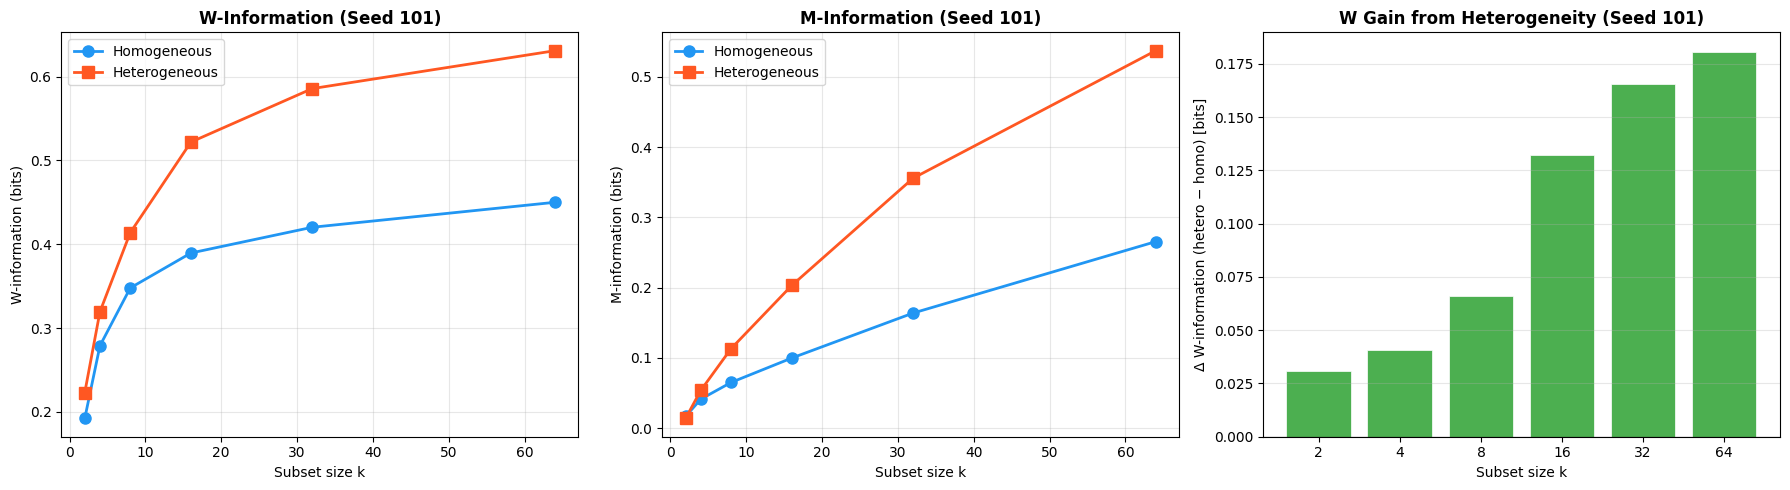


── W/M Summary (Seed 101) ──
  k     ΔW (bits)     ΔM (bits)     W_ratio
  2      +0.03081      -0.00273       1.160x
  4      +0.04056      +0.01244       1.145x
  8      +0.06597      +0.04812       1.190x
 16      +0.13230      +0.10326       1.340x
 32      +0.16539      +0.19181       1.394x
 64      +0.18081      +0.27161       1.402x


In [40]:
homo = wm_df[wm_df["role"] == "homo"].sort_values("k")
hetero = wm_df[wm_df["role"] == "hetero"].sort_values("k")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# W-information
ax = axes[0]
ax.plot(homo["k"], homo["W_bits"], "o-", color="#2196F3", linewidth=2, markersize=8, label="Homogeneous")
ax.plot(hetero["k"], hetero["W_bits"], "s-", color="#FF5722", linewidth=2, markersize=8, label="Heterogeneous")
ax.set_xlabel("Subset size k"); ax.set_ylabel("W-information (bits)")
ax.set_title(f"W-Information (Seed {WM_SEED})", fontweight="bold")
ax.legend(); ax.grid(True, alpha=0.3)

# M-information Z-scores (the correct comparison metric)
ax = axes[1]
ax.plot(homo["k"], homo["z_M"], "o-", color="#2196F3", linewidth=2, markersize=8, label="Homogeneous")
ax.plot(hetero["k"], hetero["z_M"], "s-", color="#FF5722", linewidth=2, markersize=8, label="Heterogeneous")
ax.axhline(y=1.96, color="gray", linestyle="--", linewidth=0.8, alpha=0.7, label="p < 0.05 (two-tailed)")
ax.set_xlabel("Subset size k"); ax.set_ylabel("M Z-score (time-shuffle null)")
ax.set_title(f"M-Info Z-Scores (Seed {WM_SEED})", fontweight="bold")
ax.legend(fontsize=8); ax.grid(True, alpha=0.3)

# Δz_M = hetero_z - homo_z 
ax = axes[2]
delta_z = hetero["z_M"].values - homo["z_M"].values
colors = ["#4CAF50" if d > 0 else "#F44336" for d in delta_z]
ax.bar(range(len(WM_SUBSET_SIZES)), delta_z, color=colors, edgecolor="white", linewidth=0.5)
ax.set_xticks(range(len(WM_SUBSET_SIZES))); ax.set_xticklabels(WM_SUBSET_SIZES)
ax.set_xlabel("Subset size k"); ax.set_ylabel("Δ Z-score (hetero − homo)")
ax.set_title(f"M Z-Score Gain from Heterogeneity (Seed {WM_SEED})", fontweight="bold")
ax.axhline(y=0, color="black", linewidth=0.8); ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout(); plt.show()

print(f"\n── W/M + Z-Score Summary (Seed {WM_SEED}) ──")
print(f"{'k':>3}  {'ΔW':>10}  {'ΔM':>10}  {'Δz_M':>10}  {'W_ratio':>10}")
for i, k in enumerate(WM_SUBSET_SIZES):
    dw = hetero["W_bits"].values[i] - homo["W_bits"].values[i]
    dm = hetero["M_bits"].values[i] - homo["M_bits"].values[i]
    dz = delta_z[i]
    wr = hetero["W_bits"].values[i] / homo["W_bits"].values[i] if homo["W_bits"].values[i] > 0 else float("inf")
    print(f"{k:>3}  {dw:>+10.5f}  {dm:>+10.5f}  {dz:>+10.1f}  {wr:>10.3f}x")


### 7.5 How to Interpret

- **Silent neurons:** Must be excluded before W/M estimation. They contribute zero information and inflate subset counts artificially. If silent neurons are detected, re-run the analysis with only active neurons.

- **W-information (higher = better for heterogeneity):** Measures how much unique/predictive information each source neuron contributes. Heterogeneous τ_m should produce higher W, especially at larger k, because diverse timescales let neurons capture complementary aspects of the input dynamics.

- **M Z-scores (the correct comparison metric):** Raw M values scale with total TDMI and are not comparable across networks. Z-scoring against the time-shuffle null normalizes M by the null standard deviation, making values comparable across homo/hetero, across subset sizes, and across seeds. A z > 1.96 indicates statistically significant M-information (p < 0.05, two-tailed).

- **ΔZ (hetero − homo):** A positive ΔZ means the heterogeneous network has more statistically significant M-information — i.e., its higher-order structure exceeds what independent neurons would produce, and it exceeds this more than the homogeneous network does.

- **ΔW (hetero − homo):** The key information-theoretic metric. A positive ΔW that grows with k supports the hypothesis that τ_m heterogeneity increases unique information capacity.

- **W_ratio:** How many times more unique information the heterogeneous network extracts per neuron subset. Values >1.0 at k=64 indicate heterogeneity increases information-theoretic efficiency.
